# O'Reilly et al. (1963): Warfarin Pharmacokinetics

Here, we illustrate how `delicatessen` can be used to estimate various pharmacokinetic model parameters from dose-concentration data. To illustrate these concepts, data on warfarin (a blood thinner) are considered. Data comes from O'Reilly et al. (1963) and consists of 32 patients. Data can be obtained from the R package `nlmixr`.

## Setup

In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import delicatessen as deli
from delicatessen import MEstimator
from delicatessen.estimating_equations import ee_regression
from delicatessen.utilities import aggregate_efuncs

print("Versions")
print("NumPy:       ", np.__version__)
print("SciPy:       ", sp.__version__)
print("pandas:      ", pd.__version__)
print("Matplotlib:  ", mpl.__version__)
print("Delicatessen:", deli.__version__)

Versions
NumPy:        2.3.5
SciPy:        1.16.3
pandas:       2.3.3
Matplotlib:   3.10.8
Delicatessen: 4.2


In [2]:
d = pd.read_csv("data/warfarin.csv")
d['intercept'] = 1
d['dose'] = d.groupby('id')['amt'].transform('max')
d['concentration'] = d['dv']
d = d.loc[(d['dvid'] == 'cp') & (d['time'] >= 1.)].copy()

To simplify the model fitting here, we are restricting to observations that occur after 1 hour after administration of warfarin.

To help understand the dose data, below is a plot of the concentration over time for the 32 participants (note there are more than 32 points since each person has multiple concentration measurements)

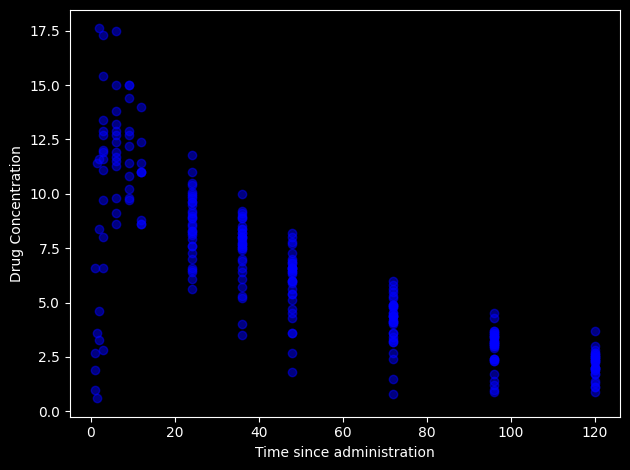

In [3]:
plt.plot(d['time'], d['dv'], 'o', color='blue', alpha=0.5)
plt.xlabel("Time since administration")
plt.ylabel("Drug Concentration")
plt.tight_layout()


We can also visualize each individuals' trajectory, which is done in the following plot

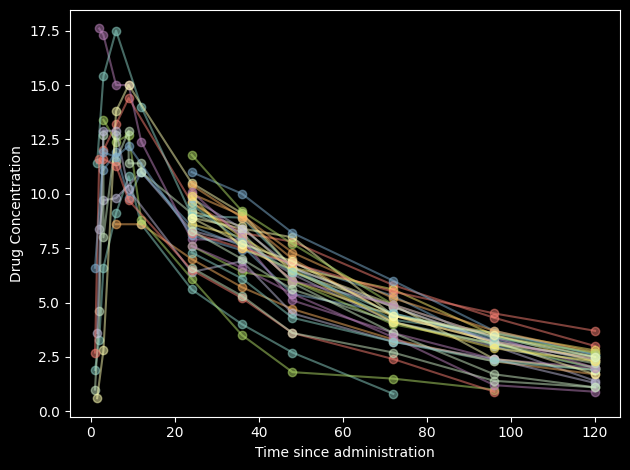

In [4]:
unique_ids = np.unique(d['id'])
for uid in unique_ids:
    ds = d.loc[d['id'] == uid].copy()
    plt.plot(ds['time'], ds['dv'], 'o-', alpha=0.5)

plt.xlabel("Time since administration")
plt.ylabel("Drug Concentration")
plt.tight_layout()

## One-Compartment IV Bolus Model

Here, we will model warfarin concentration using a one-compartment IV bolus model. This model is defined as
$$ C(t) = \frac{D}{V} \exp(-k t) $$
where $C$ is the concentration, $D$ is the dose, $V$ is the volume of distribution, $k$ is the elimination rate constant, and $t$ is the corresponding time after dose administration.

By taking the natural log of both sides, we obtain the following equality
$$ \log(C) = \log(D) - \log(V) - kt $$
which tells us that we can estimate the parameters of this model ($V,k$) using a linear regression model where the outcome (concentration) is log-transformed and the log-transformed dose is included as an offset set (since participants' doses were different). This can easily be done in `delicatessen` with the `ee_regression` function.

One caution to note is that participants contribute multiple observations to this function. In other words, the rows in our data are not independent. To account for this, we can use the `aggregate_efuncs` utility which will collapse (and thus correct) the sandwich variance for clustered data.

The following code estimates the parameters of this IV bolus model

In [5]:
def psi(theta):
    psi_i = ee_regression(theta=theta, y=np.log(d['dv']), X=d[['intercept', 'time']],
                          model='linear', offset=np.log(d['dose']))
    return aggregate_efuncs(psi_i, group=d['id'])

In [6]:
estr = MEstimator(psi, init=[0., 0.])
estr.estimate()

In [7]:
estr.print_results()

              Estimation Method: M-estimator
--------------------------------------------------------------
No. Observations:          32 | No. Parameters:              2
Solving algorithm:         lm | Max Iterations:           5000
Solving tolerance:      1e-09 | Allow P-Inverse:             1
Derivative Method:     approx | Deriv Approx:            1e-09
Small N Correction:      None | Distribution:           Z-stat
   Theta   StdErr  Z-score      LCL      UCL  P-value  S-value 
--------------------------------------------------------------
   -2.21     0.07   -29.56    -2.36    -2.07     0.00   635.37 
   -0.01     0.00   -16.85    -0.02    -0.01     0.00   209.33 


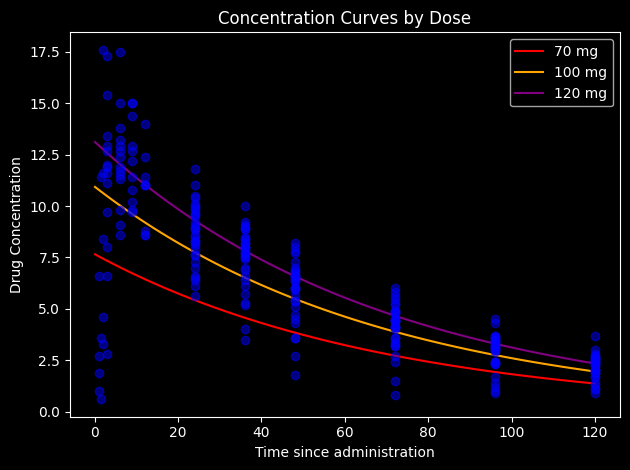

In [8]:
time_range = np.linspace(0.1, 120, 100)
conc_70 = np.exp(estr.theta[0] + estr.theta[1]*time_range + np.log(70))
conc_100 = np.exp(estr.theta[0] + estr.theta[1]*time_range + np.log(100))
conc_120 = np.exp(estr.theta[0] + estr.theta[1]*time_range + np.log(120))

plt.plot(time_range, conc_70, '-', color='red', label='70 mg')
plt.plot(time_range, conc_100, '-', color='orange', label='100 mg')
plt.plot(time_range, conc_120, '-', color='purple', label='120 mg')
plt.plot(d['time'], d['dv'], 'o', color='blue', alpha=0.5)
plt.title("Concentration Curves by Dose")
plt.xlabel("Time since administration")
plt.ylabel("Drug Concentration")
plt.legend()
plt.tight_layout()

The plot shows the estimated concentration curve for a few initial doses for the original data range.

Recall that we need to transform these estimated parameters to get $V,k$. The following code transforms the parameters from this linear model to the desired parameters

In [9]:
theta = estr.theta
ci = estr.confidence_intervals()

print("Volume of Distribution")
print(1 / np.exp(theta[0]))
print("95% CI:", 1 / np.exp(ci[0, :]))
print("\nElimination Rate Constant")
print(-theta[1])
print("95% CI:", -ci[1, :])

Volume of Distribution
9.137603593434688
95% CI: [10.58150656  7.89072888]

Elimination Rate Constant
0.014378463291613155
95% CI: [0.01605045 0.01270648]


Note that the confidence intervals here are flipped (upper is first and lower is second) because of the inverting and negation respectively.

## IV Bolus Model Parameters

In addition to $V,k$, there are often other parameters of interest from an IV bolus model. These other parameters are transformations of the $V,k$ parameters. Inference for these additional parameters is made easy through stacking corresponding estimating functions. Here we consider two additional parameters: half-life ($\log(2) / k$) and clearance ($k \times V$). The following estimating function adds these additional parameters to the previous and solves for them

In [10]:
def psi_pk_i(theta):
    v_inv = theta[0]
    v = 1 / np.exp(v_inv)
    k_neg = theta[1]
    k = -k_neg
    half_life = theta[2]
    clearance = theta[3]
    n = d.shape[0]

    # IV bolus model estimating function
    ee_ivb = ee_regression(theta=[v_inv, k_neg], y=np.log(d['dv']), X=d[['intercept', 'time']],
                          model='linear', offset=np.log(d['dose']))

    # Half-life estimating function
    ee_hlife = (np.log(2) / k - half_life) * np.ones(n)

    # Clearance estimating function
    ee_clr = (v*k - clearance) * np.ones(n)

    return np.vstack([ee_ivb, ee_hlife, ee_clr])

def psi_pk_g(theta):
    return aggregate_efuncs(psi_pk_i(theta), group=d['id'])

In [11]:
estr = MEstimator(psi_pk_g, init=[-2., -0.01, 1., 1.])
estr.estimate()

In [12]:
theta = estr.theta
ci = estr.confidence_intervals()

print("Half-Life")
print(theta[2])
print("95% CI:", ci[2, :])
print("\nClearance")
print(theta[3])
print("95% CI:", ci[3, :])

Half-Life
48.20731996890464
95% CI: [42.60158145 53.81305849]

Clearance
0.13138469784151308
95% CI: [0.11831647 0.14445293]


This example highlights how estimating equations can simplify inference with pharmacokinetic models. In particular, the automation of the delta method (via the sandwich variance) makes it straightforward to compute the variance of transformations of different parameters.

## References

O'Reilly RA, Aggeler PM, Leong LS. Studies of the coumarin anticoagulant drugs: The pharmacodynamics of warfarin in man. Journal of Clinical Investigation 1963; 42(10): 1542-1551